# 05 — XGBoost Model

**Workstream**: Modeling — XGBoost  ·  **Owner**: Deepak (backup: Bella)  ·  **Last touched**: 2026-06-02

**What this notebook decides**

Train and evaluate a calibrated XGBoost classifier on the **same feature
contract** and **same temporal split** as notebook 04 (the LogReg baseline).
Direct A/B comparison.

Per CLAUDE.md, XGBoost is the production estimator iff it clears the
baseline on **both**:
  - **PR-AUC** (headline metric)
  - **Precision@10%** (operational metric)

Baseline target to beat (from `reports/metrics/baseline_*.json`):
  - PR-AUC  test: ~0.238
  - Precision@10% test: ~28.9%

**Why XGBoost should win**
  - Captures non-linear interactions LogReg can't (e.g. high `prior_fails`
    *and* short `days_since_last_inspection` *and* dense `n_311_rodent`
    zip — interaction term LogReg has no access to).
  - Handles missing values natively, retaining the "first inspection at
    license" signal that median-imputation in LogReg destroys.
  - Partition-based categorical splits avoid the one-hot explosion of
    `static_zip` (~60 levels).

Per CLAUDE.md: `scale_pos_weight` (not SMOTE). Class-imbalance handling
via loss re-weighting only.

**Deliverables**
- `data/models/xgb_<YYYYMMDD>.joblib` — calibrated estimator
- `data/models/xgb_<YYYYMMDD>_metadata.json` — split cutoffs, hyperparameters, metrics
- `reports/metrics/xgb_<YYYYMMDD>.json` — git-tracked metrics report

## 1. Setup

In [1]:
import sys
import json
from datetime import date
from pathlib import Path

_PROJECT_ROOT = Path.cwd().parent
if str(_PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT / 'src'))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV

from foodsafety.config import MODELS_DIR, PROCESSED_DIR, RANDOM_STATE
from foodsafety.utils.time import temporal_split, summarize
from foodsafety.models.baseline import ALL_FEATURES, LABEL_COL
from foodsafety.models.xgb import (
    build_xgb_estimator, prepare_xgb_features,
    extract_categorical_dtypes, compute_scale_pos_weight,
)
from foodsafety.models.evaluate import (
    evaluate, decile_lift_table, calibration_table,
)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Load + split (same cutoffs as 04)

Re-use the cutoffs from the baseline notebook. If they ever change there,
they must change here too. Wiring a shared constant would help; keeping them
as a literal here for now so the diff is visible across notebooks.

In [2]:
features_path = PROCESSED_DIR / 'features.parquet'
features = pd.read_parquet(features_path)
features['inspection_date'] = pd.to_datetime(features['inspection_date'])
for c in features.columns:
    if c.startswith('flag_kw_'):
        features[c] = features[c].astype('int8')

TRAIN_END = '2024-07-01'
VAL_END   = '2025-07-01'

split = temporal_split(features, train_end=TRAIN_END, val_end=VAL_END)
for name, frame in [('train', split.train), ('val', split.val), ('test', split.test)]:
    s = summarize(frame, label_col=LABEL_COL)
    print(f'  {name:<5}  n={s.rows:>6,}  '
          f'dates {s.date_min.date()} → {s.date_max.date()}  '
          f'positive_rate={s.positive_rate:.2%}')

  train  n=79,268  dates 2019-01-02 → 2024-06-28  positive_rate=14.45%
  val    n=16,564  dates 2024-07-01 → 2025-06-27  positive_rate=10.53%
  test   n=13,598  dates 2025-07-01 → 2026-06-05  positive_rate=8.77%


## 3. Prepare features for XGBoost

XGBoost reads pandas `category` dtype natively when `enable_categorical=True`.
Critical: the category levels must align across train/val/test so the
internal codes match. We infer levels from train, then reuse them on val
and test.

In [3]:
X_train_raw = split.train[ALL_FEATURES]
y_train     = split.train[LABEL_COL].astype(int)
X_val_raw   = split.val  [ALL_FEATURES]
y_val       = split.val  [LABEL_COL].astype(int)
X_test_raw  = split.test [ALL_FEATURES]
y_test      = split.test [LABEL_COL].astype(int)

X_train = prepare_xgb_features(X_train_raw)
cat_dtypes = extract_categorical_dtypes(X_train)
X_val  = prepare_xgb_features(X_val_raw,  categorical_dtypes=cat_dtypes)
X_test = prepare_xgb_features(X_test_raw, categorical_dtypes=cat_dtypes)

print('Train dtypes after prep:')
print(X_train.dtypes.value_counts())

spw = compute_scale_pos_weight(y_train)
print(f'\nscale_pos_weight (n_neg/n_pos in train) = {spw:.3f}')

Train dtypes after prep:
int8        12
float32     11
category     1
category     1
category     1
Name: count, dtype: int64

scale_pos_weight (n_neg/n_pos in train) = 5.919


## 4. Fit with early stopping

Train on train, monitor val, stop when val PR-AUC stops improving for 40
rounds. The fitted estimator is then frozen and an isotonic calibrator is
fit against val predictions.

**Methodological note**: val is used twice here — once for early stopping,
once for calibration. This is a mild double-dip but is the same pattern as
notebook 04 (the baseline used val for calibration too). Test is still
fully held out. If we ever want to be more rigorous, split train into
train_fit + train_calib.

In [4]:
%%time
xgb = build_xgb_estimator(
    scale_pos_weight=spw,
    early_stopping_rounds=40,
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
print(f'Best iteration:  {xgb.best_iteration}')
print(f'Best val aucpr:  {xgb.best_score:.4f}')

Best iteration:  142
Best val aucpr:  0.2674
CPU times: user 8.14 s, sys: 163 ms, total: 8.3 s
Wall time: 4.4 s


In [5]:
# Calibrate via isotonic on val. cv='prefit' tells sklearn not to refit
# the inner estimator — only the calibration mapping is learned.
model = CalibratedClassifierCV(xgb, method='isotonic', cv='prefit')
model.fit(X_val, y_val)
print('Calibrated.')

Calibrated.


/opt/conda/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


## 5. Evaluate

In [6]:
val_scores  = model.predict_proba(X_val)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]

val_report  = evaluate(y_val,  val_scores)
test_report = evaluate(y_test, test_scores)

# Load baseline test metrics for A/B comparison
baseline_reports = sorted((_PROJECT_ROOT / 'reports' / 'metrics').glob('baseline_*.json'))
if baseline_reports:
    baseline_test = json.loads(baseline_reports[-1].read_text())['test']
else:
    baseline_test = None
    print('No baseline metrics found — skipping A/B comparison.')

out = {'val':  val_report.to_dict(),
       'test': test_report.to_dict()}
if baseline_test is not None:
    out['baseline_test'] = baseline_test
    out['delta_vs_baseline'] = {
        k: round(test_report.to_dict()[k] - baseline_test[k], 4)
        for k in ['pr_auc', 'roc_auc', 'precision_at_5pct',
                  'precision_at_10pct', 'precision_at_20pct',
                  'top_decile_lift', 'brier_score']
    }

print(pd.DataFrame(out).round(4).to_string())

                           val        test  baseline_test  delta_vs_baseline
n                   16564.0000  13598.0000     13070.0000                NaN
positive_rate           0.1053      0.0877         0.0875                NaN
pr_auc                  0.2623      0.2471         0.2516            -0.0046
roc_auc                 0.7442      0.7668         0.7733            -0.0064
precision_at_5pct       0.3727      0.3559         0.3517             0.0042
precision_at_10pct      0.3120      0.2956         0.2953             0.0003
precision_at_20pct      0.2508      0.2346         0.2372            -0.0026
top_decile_lift         2.9634      3.3692         3.3771            -0.0079
brier_score             0.0859      0.0730         0.0725             0.0005
log_loss                0.2976      0.2768         0.2694                NaN


### 5a. Did XGBoost beat the baseline?

CLAUDE.md requires clearing both PR-AUC and precision@10%.

In [7]:
if baseline_test is not None:
    pr_auc_delta = test_report.pr_auc - baseline_test['pr_auc']
    p10_delta    = test_report.precision_at_10pct - baseline_test['precision_at_10pct']
    print(f'PR-AUC          : baseline {baseline_test["pr_auc"]:.4f}  →  '
          f'XGB {test_report.pr_auc:.4f}  ({pr_auc_delta:+.4f})')
    print(f'Precision@10%   : baseline {baseline_test["precision_at_10pct"]:.4f}  →  '
          f'XGB {test_report.precision_at_10pct:.4f}  ({p10_delta:+.4f})')
    if pr_auc_delta > 0 and p10_delta > 0:
        print('\n✓ XGBoost beats baseline on BOTH metrics.')
        print('  → Production estimator candidate.')
    elif pr_auc_delta > 0 or p10_delta > 0:
        print('\n△ XGBoost beats baseline on ONE metric, not both.')
        print('  → Investigate before promoting. May need tuning / better features.')
    else:
        print('\n✗ XGBoost does not beat baseline.')
        print('  → Likely a feature problem, not a model problem. Stay with baseline.')

PR-AUC          : baseline 0.2516  →  XGB 0.2471  (-0.0046)
Precision@10%   : baseline 0.2953  →  XGB 0.2956  (+0.0003)

△ XGBoost beats baseline on ONE metric, not both.
  → Investigate before promoting. May need tuning / better features.


### 5b. Decile lift (TEST)

Per-decile positive rate. Decile 1 = top 10% predicted scores.

In [8]:
lift = decile_lift_table(y_test, test_scores)
print(lift.to_string())

           n  positive_rate  mean_score  lift_vs_base
decile                                               
1       1360         0.2956      0.3000        3.3692
2       1360         0.1735      0.1861        1.9779
3       1360         0.1029      0.1502        1.1733
4       1359         0.1052      0.1181        1.1994
5       1360         0.0522      0.0862        0.5951
6       1360         0.0515      0.0720        0.5867
7       1359         0.0375      0.0543        0.4277
8       1360         0.0265      0.0474        0.3017
9       1360         0.0221      0.0291        0.2514
10      1360         0.0103      0.0111        0.1173


### 5c. Calibration (TEST)

   bin  mean_predicted  mean_observed
0    1          0.0113         0.0114
1    2          0.0324         0.0234
2    3          0.0477         0.0291
3    4          0.0571         0.0401
4    5          0.0774         0.0461
5    6          0.1136         0.1000
6    7          0.1286         0.0952
7    8          0.1588         0.1130
8    9          0.1934         0.1830
9   10          0.3122         0.3055


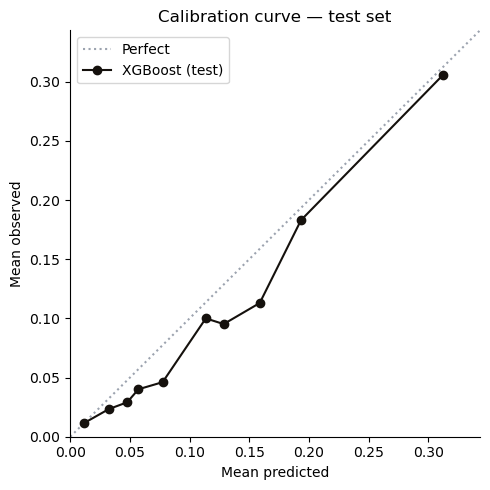

In [9]:
calib = calibration_table(y_test, test_scores, n_bins=10)
print(calib.to_string())

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], color='#9CA3AF', linestyle=':', label='Perfect')
ax.plot(calib['mean_predicted'], calib['mean_observed'], 'o-', color='#15110D',
        label='XGBoost (test)')
ax.set_xlabel('Mean predicted'); ax.set_ylabel('Mean observed')
ax.set_title('Calibration curve — test set'); ax.legend()
lim = max(calib['mean_predicted'].max(), calib['mean_observed'].max()) * 1.1
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout(); plt.show()

### 5d. Feature importance (gain)

Top 15 features by XGBoost's gain-based importance. This is the cheap,
interpretable view — SHAP (notebook 06) is the formal one.

Top 15 features by gain:
flag_kw_pest                     0.3051
flag_kw_handwash_sink            0.2125
flag_kw_temperature              0.0853
flag_kw_rodent                   0.0459
flag_kw_sewage                   0.0293
flag_kw_certified_manager        0.0251
flag_kw_cross_contamination      0.0247
static_zip                       0.0218
flag_kw_cooling                  0.0213
prior_fail_or_priority_events    0.0198
flag_kw_expired                  0.0190
prior_priority_violations        0.0185
static_facility_type             0.0170
license_age_days                 0.0169
temporal_quarter                 0.0146


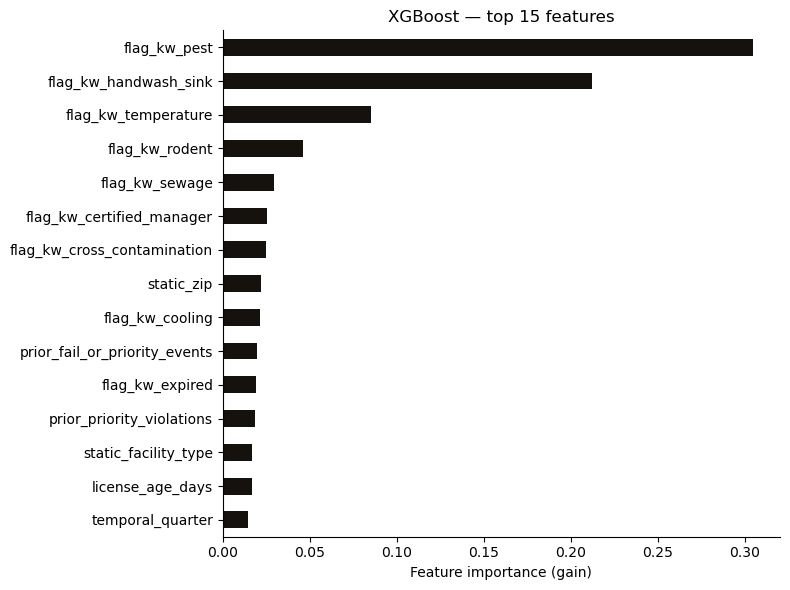

In [10]:
importances = pd.Series(xgb.feature_importances_, index=ALL_FEATURES)
top15 = importances.sort_values(ascending=False).head(15)
print('Top 15 features by gain:')
print(top15.round(4).to_string())

ax = top15[::-1].plot.barh(color='#15110D', figsize=(8, 6))
ax.set_xlabel('Feature importance (gain)')
ax.set_title('XGBoost — top 15 features')
plt.tight_layout(); plt.show()

### 5e. Correlation matrix + comparison with XGBoost gain (top 15)

Pearson correlation of numeric features against the label (train set), compared to XGBoost gain importance.
High gain + low correlation → XGBoost is exploiting non-linear structure.
High correlation + low gain → feature may be redundant or collinear with another.

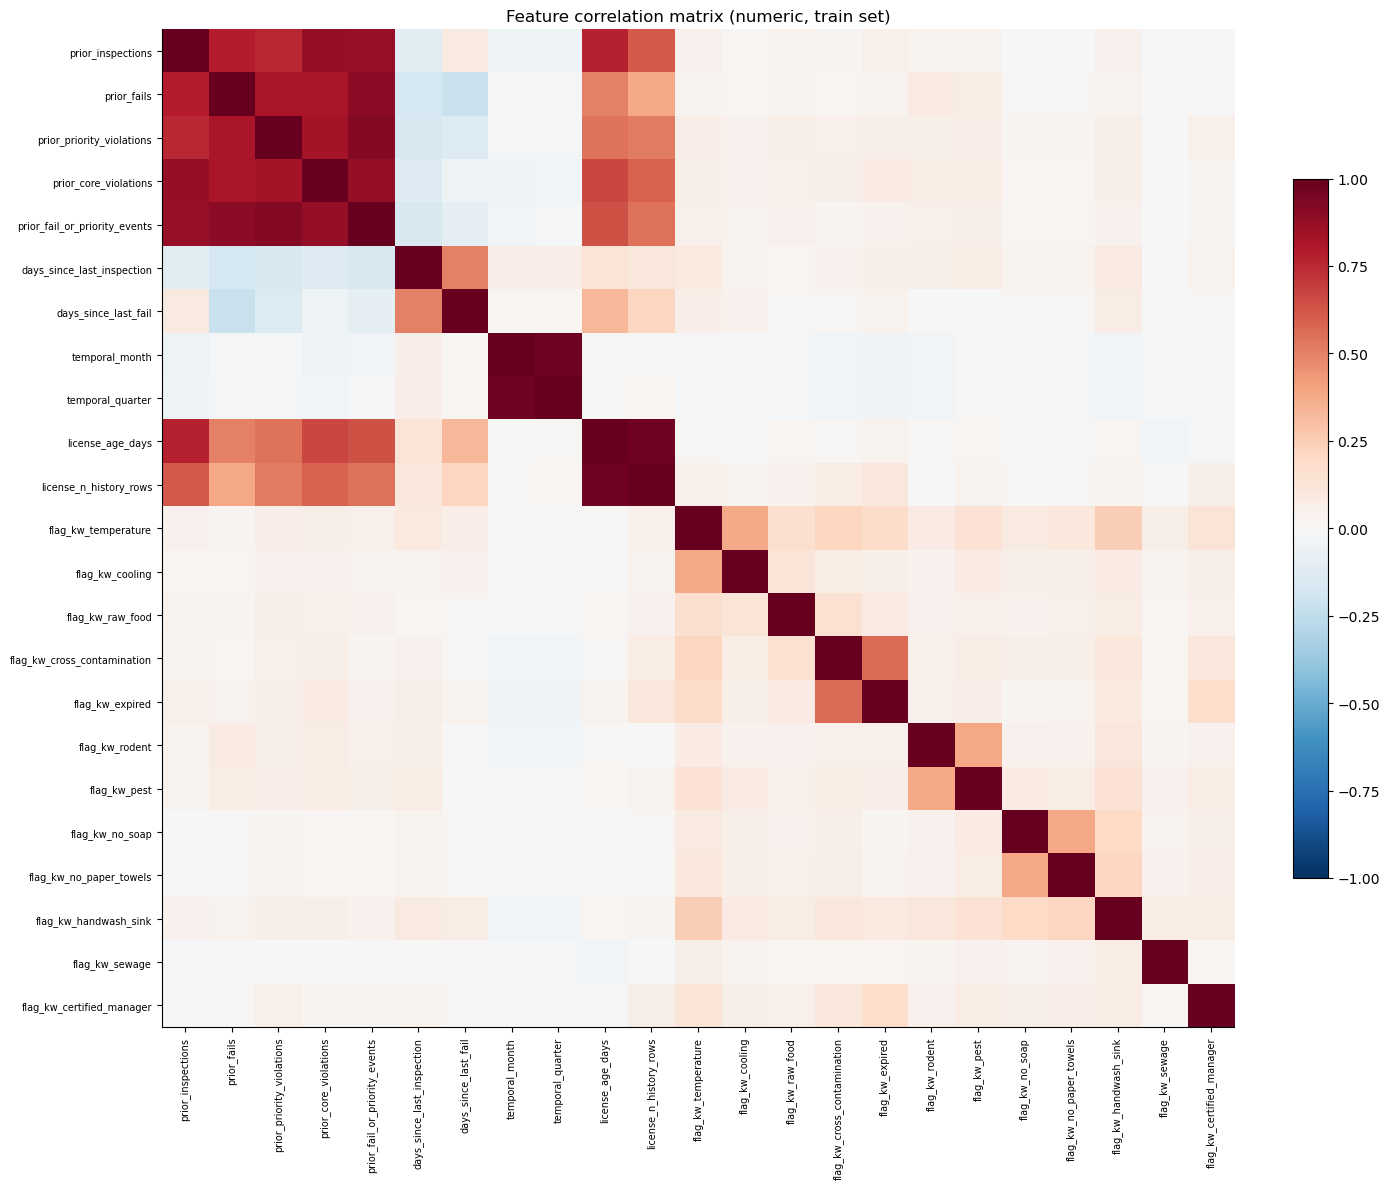

Feature comparison — |corr with label| vs normalised XGB gain (top 25):
                               corr_with_label  xgb_gain_norm
flag_kw_pest                            0.2222         1.0000
flag_kw_handwash_sink                   0.1994         0.6963
flag_kw_temperature                     0.1917         0.2797
flag_kw_rodent                          0.1795         0.1506
flag_kw_sewage                          0.0632         0.0960
flag_kw_certified_manager               0.0844         0.0824
flag_kw_cross_contamination             0.1223         0.0810
flag_kw_cooling                         0.1226         0.0699
prior_fail_or_priority_events           0.0894         0.0648
flag_kw_expired                         0.1069         0.0624
prior_priority_violations               0.1058         0.0606
license_age_days                        0.0109         0.0555
temporal_quarter                        0.0283         0.0478
flag_kw_raw_food                        0.0734         0.047

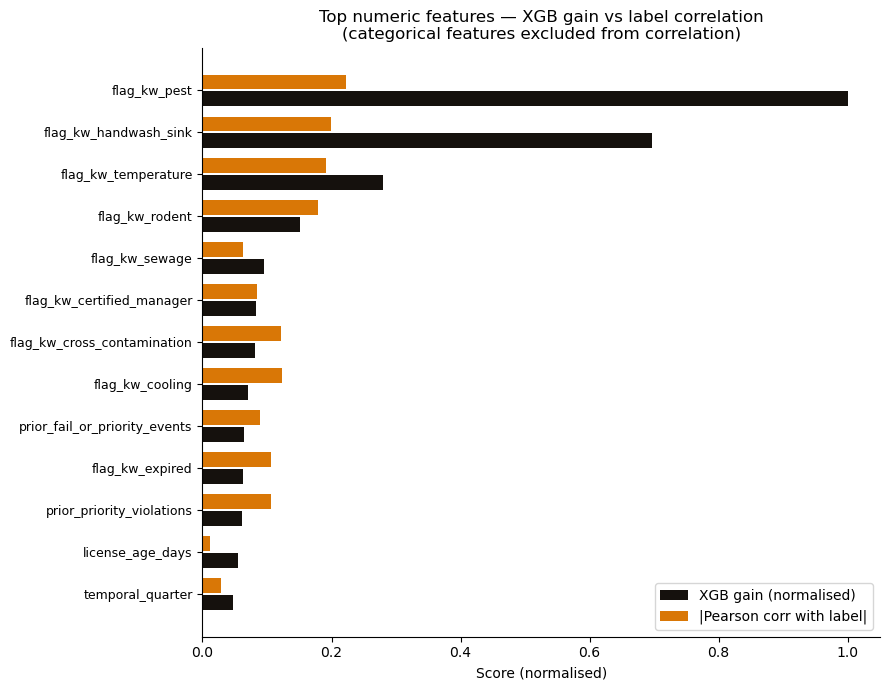


Features with strong non-linear signal (gain − corr > 0.3):
                       xgb_gain_norm  corr_with_label
flag_kw_handwash_sink         0.6963           0.1994
flag_kw_pest                  1.0000           0.2222

Categorical features in top-15 gain (no Pearson corr): ['static_zip', 'static_facility_type']


In [13]:
# --- Correlation matrix of numeric features (train set) ---
# Exclude categoricals — Pearson correlation is not defined for them.
num_features = [f for f in ALL_FEATURES if X_train[f].dtype != 'category']
train_num = X_train[num_features].copy().astype(float)

corr_matrix = train_num.corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_xticks(range(len(num_features))); ax.set_xticklabels(num_features, rotation=90, fontsize=7)
ax.set_yticks(range(len(num_features))); ax.set_yticklabels(num_features, fontsize=7)
ax.set_title('Feature correlation matrix (numeric, train set)')
plt.tight_layout(); plt.show()

# --- Correlation with label vs XGBoost gain ---
label_corr = train_num.corrwith(y_train.astype(float)).abs().rename('corr_with_label')

xgb_gain = pd.Series(xgb.feature_importances_, index=ALL_FEATURES)
xgb_gain_norm = (xgb_gain / xgb_gain.max()).rename('xgb_gain_norm')

comparison = pd.concat([label_corr, xgb_gain_norm], axis=1).dropna()
comparison = comparison.sort_values('xgb_gain_norm', ascending=False)

print("Feature comparison — |corr with label| vs normalised XGB gain (top 25):")
print(comparison.head(25).round(4).to_string())

# Side-by-side bar chart: top 15 XGB gain features that are numeric (comparable)
top15_names = [f for f in top15.index if f in comparison.index]
comp15 = comparison.loc[top15_names].sort_values('xgb_gain_norm', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
y = range(len(comp15))
ax.barh([i - 0.2 for i in y], comp15['xgb_gain_norm'], height=0.35,
        color='#15110D', label='XGB gain (normalised)')
ax.barh([i + 0.2 for i in y], comp15['corr_with_label'], height=0.35,
        color='#D97706', label='|Pearson corr with label|')
ax.set_yticks(list(y)); ax.set_yticklabels(comp15.index, fontsize=9)
ax.set_xlabel('Score (normalised)')
ax.set_title('Top numeric features — XGB gain vs label correlation\n(categorical features excluded from correlation)')
ax.legend()
plt.tight_layout(); plt.show()

# Flag features where XGB gain >> correlation (non-linear signal)
threshold = 0.3
nl_features = comp15[comp15['xgb_gain_norm'] - comp15['corr_with_label'] > threshold]
if not nl_features.empty:
    print("\nFeatures with strong non-linear signal (gain − corr > 0.3):")
    print(nl_features[['xgb_gain_norm', 'corr_with_label']].round(4).to_string())

# Note any top-15 features that were categorical (skipped from comparison)
skipped = [f for f in top15.index if f not in comparison.index]
if skipped:
    print(f"\nCategorical features in top-15 gain (no Pearson corr): {skipped}")


## 6. Persist

Same convention as notebook 04: never overwrite, include date in filename, write metadata sidecar.

In [11]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_METRICS_DIR = _PROJECT_ROOT / 'reports' / 'metrics'
REPORTS_METRICS_DIR.mkdir(parents=True, exist_ok=True)

stamp = date.today().isoformat().replace('-', '')
model_path = MODELS_DIR / f'xgb_{stamp}.joblib'
metadata_path = MODELS_DIR / f'xgb_{stamp}_metadata.json'
report_path = REPORTS_METRICS_DIR / f'xgb_{stamp}.json'

joblib.dump(model, model_path)
print(f'saved model → {model_path}  ({model_path.stat().st_size / 1e6:.1f} MB)')

metadata = {
    'model': 'xgboost_isotonic',
    'random_state': RANDOM_STATE,
    'date_trained': date.today().isoformat(),
    'split': {
        'train_end': str(split.train_end.date()),
        'val_end':   str(split.val_end.date()),
        'train_n':   int(len(split.train)),
        'val_n':     int(len(split.val)),
        'test_n':    int(len(split.test)),
    },
    'hyperparameters': {
        'n_estimators_max': xgb.n_estimators,
        'best_iteration':   int(xgb.best_iteration),
        'best_val_aucpr':   float(xgb.best_score),
        'max_depth':        xgb.max_depth,
        'learning_rate':    xgb.learning_rate,
        'scale_pos_weight': float(spw),
        'early_stopping_rounds': xgb.early_stopping_rounds,
    },
    'features': {
        'all':       ALL_FEATURES,
        'label_col': LABEL_COL,
    },
    'metrics': {
        'val':  val_report.to_dict(),
        'test': test_report.to_dict(),
    },
    'features_parquet_mtime': pd.Timestamp(features_path.stat().st_mtime, unit='s').isoformat(),
}
with metadata_path.open('w') as f:
    json.dump(metadata, f, indent=2)
print(f'saved metadata → {metadata_path}')

with report_path.open('w') as f:
    json.dump({'model': 'xgboost', 'val': val_report.to_dict(), 'test': test_report.to_dict()}, f, indent=2)
print(f'saved report → {report_path}')

saved model → /mnt/custom-file-systems/efs/fs-08755a10ffa6eba17_fsap-095a4e2a32cbccd29/food-safety-intelligence/data/models/xgb_20260607.joblib  (2.2 MB)
saved metadata → /mnt/custom-file-systems/efs/fs-08755a10ffa6eba17_fsap-095a4e2a32cbccd29/food-safety-intelligence/data/models/xgb_20260607_metadata.json
saved report → /mnt/custom-file-systems/efs/fs-08755a10ffa6eba17_fsap-095a4e2a32cbccd29/food-safety-intelligence/reports/metrics/xgb_20260607.json


## 7. Hand-off

If XGBoost cleared the baseline on both PR-AUC and precision@10%, the model
in `data/models/xgb_<stamp>.joblib` is the **production estimator** for
notebook 06 — SHAP + scoring + `scores.parquet` + JSON export to the web app.

If XGBoost did NOT clear the baseline:
  - Stay with the baseline model in notebook 06.
  - Investigate: feature engineering miss? Categorical handling issue?
  - Don't add hyperparameter sweeps before checking the data — the
    typical fix is better features, not tuning.

**Next step**: `notebooks/06_eval_and_shap.ipynb` —
  - Per-restaurant SHAP top-drivers
  - Group-performance table by `static_facility_type` and `static_zip3`
  - Write `data/predictions/scores.parquet` and `app/public/data/scores.json`
    (the web app auto-drops the demo banner when the real one lands)

**Sanity to confirm before moving on**:
  - XGB beats baseline on PR-AUC AND precision@10%, OR a decision has been
    documented to ship baseline instead
  - Calibration curve is roughly on the diagonal
  - Top-importance feature list reads sensibly (`prior_*` should dominate;
    if `static_zip` is #1 you may have a leak you didn't realise)
  - `tests/` still all green